In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

Data Understanding

In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Records:")
display(df.head())

print("\nTarget Distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn             

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


Dataset Profiling

In [3]:
print(df.info())

print("\nStatistical Summary")
display(df.describe())

print("\nCategorical Summary")
display(df.describe(include='object'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Categorical Summary


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


Missing Value Treatment

In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
#TotalCharges Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].isnull().sum())

11


In [6]:
#Fill Missing Values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_726/2364547829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [7]:
#Verify
print(df.isnull().sum().sum())

0


Duplicate handling

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [9]:
#Remove Duplicates
df = df.drop_duplicates()

print(df.shape)

(7043, 21)


Outiler analysis

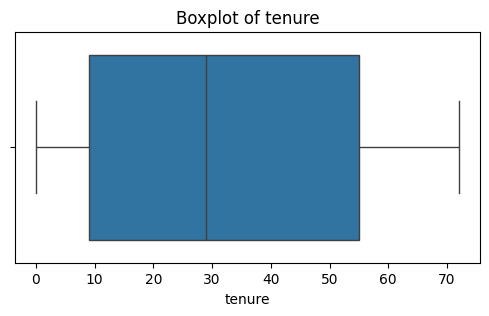

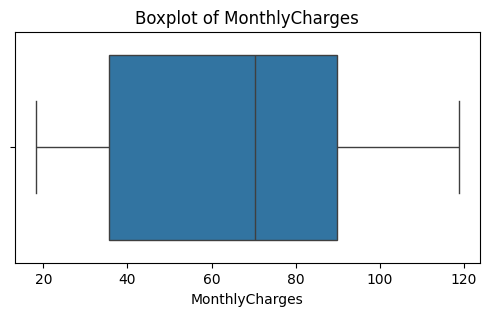

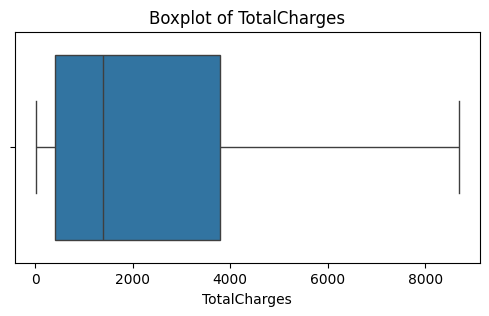

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['tenure','MonthlyCharges','TotalCharges']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

IQR

In [11]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

tenure : 0
MonthlyCharges : 0
TotalCharges : 0


FEATURE ENGINEERING

In [12]:
#Feature Engineering
#Drop Customer ID
df.drop('customerID', axis=1, inplace=True)

In [13]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [14]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df[col] = df[col].astype('category').cat.codes

ONE HOT ENCODING

In [15]:
df = pd.get_dummies(df, drop_first=True)

VISUALIZATION

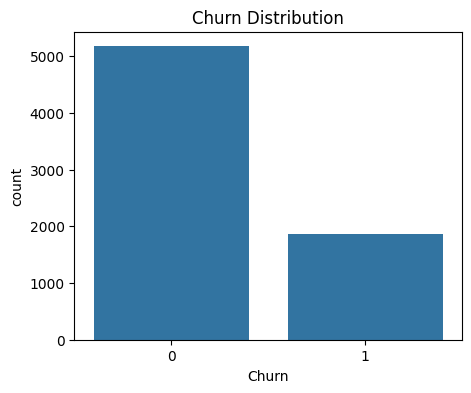

In [16]:
plt.figure(figsize=(5,4))

sns.countplot(x='Churn', data=df)

plt.title("Churn Distribution")
plt.show()

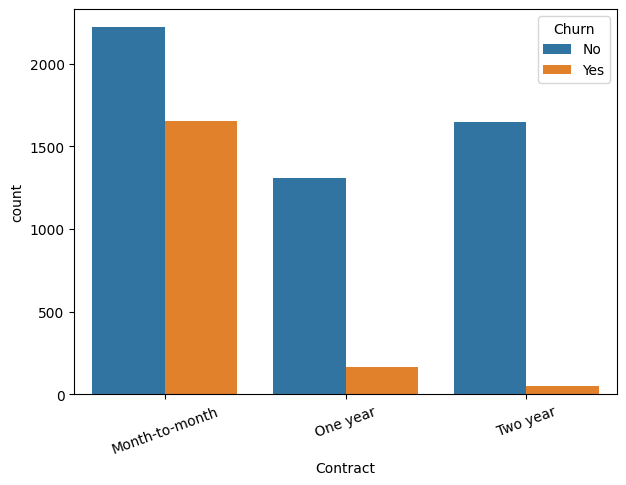

In [17]:
#CONTRACT VS CHURN
contract_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

plt.figure(figsize=(7,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=contract_df
)

plt.xticks(rotation=20)
plt.show()

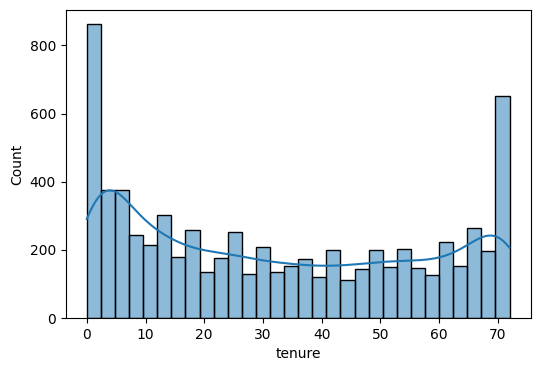

In [18]:
#Tenure Distribution
plt.figure(figsize=(6,4))

sns.histplot(
    contract_df['tenure'],
    bins=30,
    kde=True
)

plt.show()

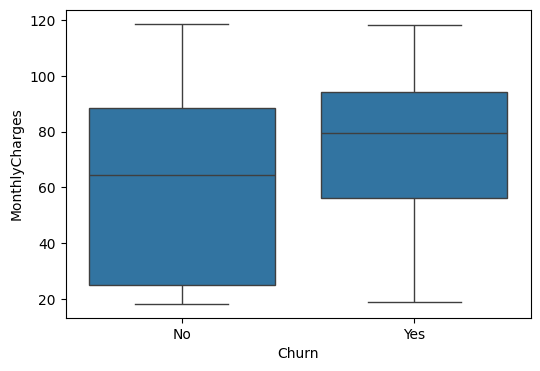

In [19]:
#Monthly Charges vs Churn
plt.figure(figsize=(6,4))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=contract_df
)

plt.show()

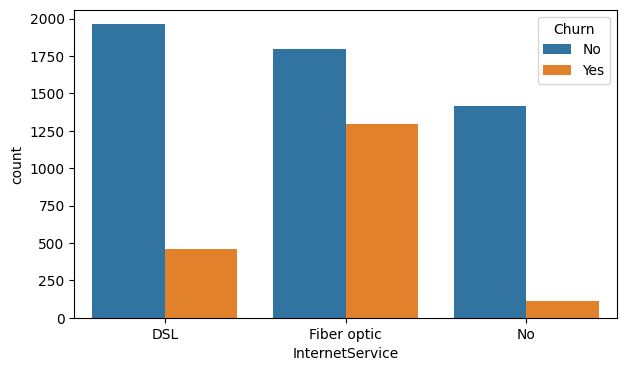

In [20]:
#Internet Service vs Churn
plt.figure(figsize=(7,4))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=contract_df
)

plt.show()

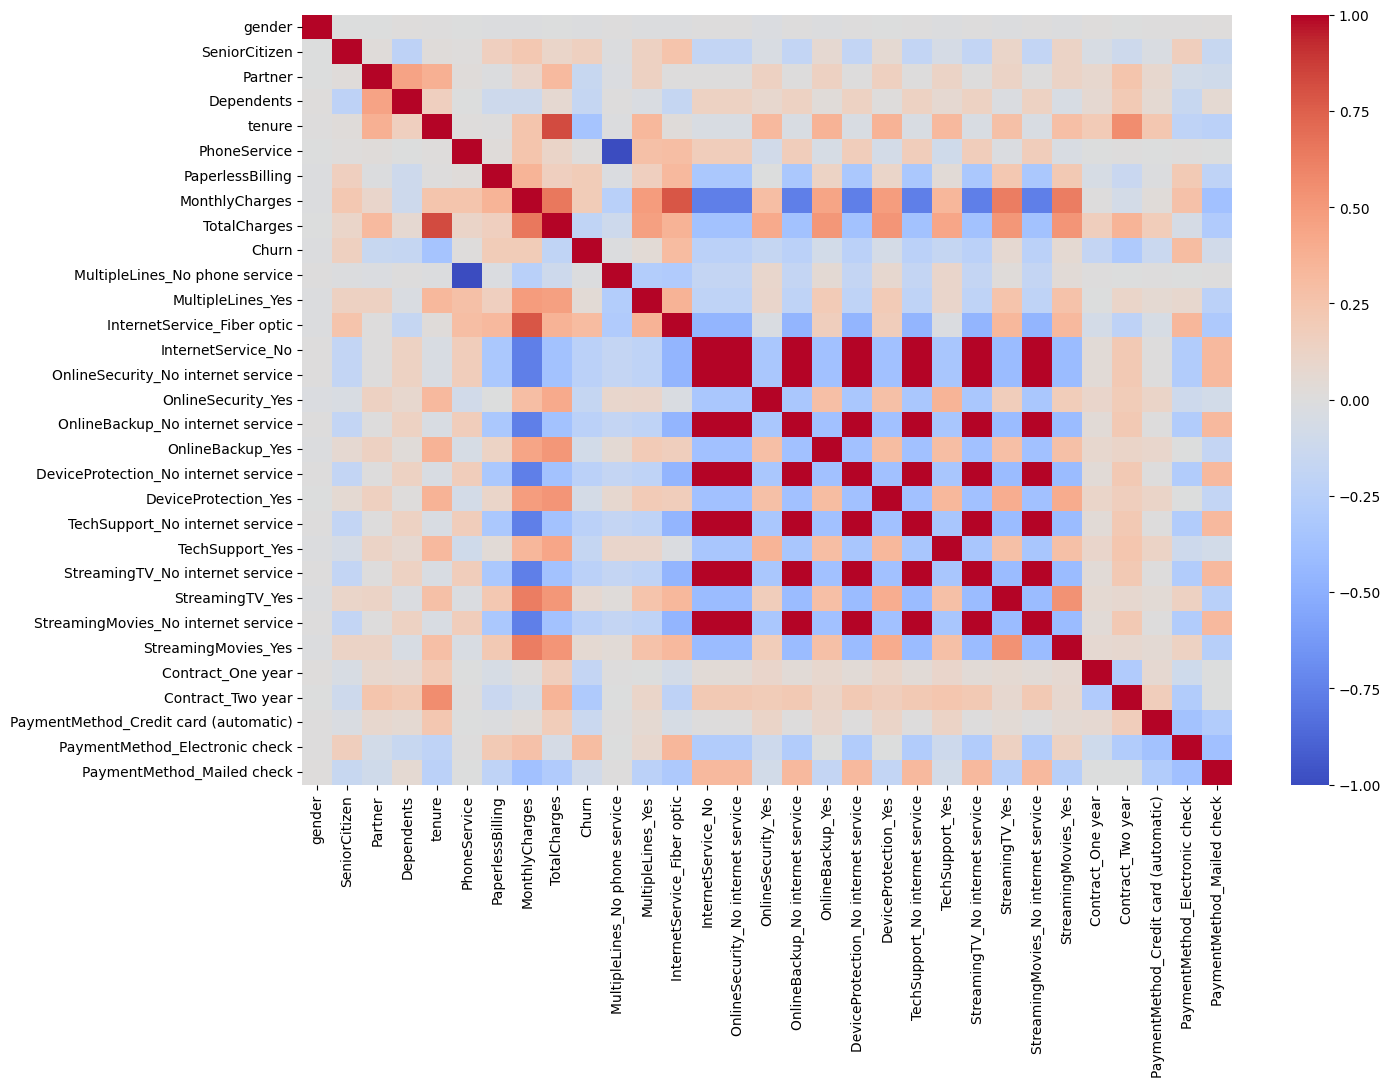

In [21]:
#Correlation Analysis
plt.figure(figsize=(15,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

In [22]:
#Top Correlations with Churn
corr_target = df.corr()['Churn']

print(
    corr_target.sort_values(
        ascending=False
    ).head(10)
)

print(
    corr_target.sort_values().head(10)
)

Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService                      0.011942
Name: Churn, dtype: float64
tenure                                 -0.352229
Contract_Two year                      -0.302253
InternetService_No                     -0.227890
OnlineSecurity_No internet service     -0.227890
DeviceProtection_No internet service   -0.227890
StreamingTV_No internet service        -0.227890
OnlineBackup_No internet service       -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
TotalCharges                           -0.199037
Name: Churn, dtype: float64


In [23]:
#Dataset Splitting
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)

y = df['Churn']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


In [24]:
#Feature Selection

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

selector = SelectKBest(
    score_func=chi2,
    k=15
)

X_new = selector.fit_transform(X,y)

selected_features = X.columns[
    selector.get_support()
]

print(selected_features)

Index(['tenure', 'MonthlyCharges', 'TotalCharges',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service',
       'DeviceProtection_No internet service',
       'TechSupport_No internet service', 'StreamingTV_No internet service',
       'StreamingMovies_No internet service', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Electronic check'],
      dtype='object')


In [25]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [27]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [28]:
#Performance Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [29]:
#Logistic Regression Metrics
print("Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print("Precision:",
      precision_score(y_test,y_pred_lr))

print("Recall:",
      recall_score(y_test,y_pred_lr))

print("F1:",
      f1_score(y_test,y_pred_lr))

Accuracy: 0.8048261178140526
Precision: 0.6561514195583596
Recall: 0.5561497326203209
F1: 0.6020260492040521


In [30]:
#Random Forest Metrics
print("Accuracy:",
      accuracy_score(y_test,y_pred_rf))

print("Precision:",
      precision_score(y_test,y_pred_rf))

print("Recall:",
      recall_score(y_test,y_pred_rf))

print("F1:",
      f1_score(y_test,y_pred_rf))

Accuracy: 0.78708303761533
Precision: 0.6267123287671232
Recall: 0.4893048128342246
F1: 0.5495495495495496


In [31]:
#Classification Report
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



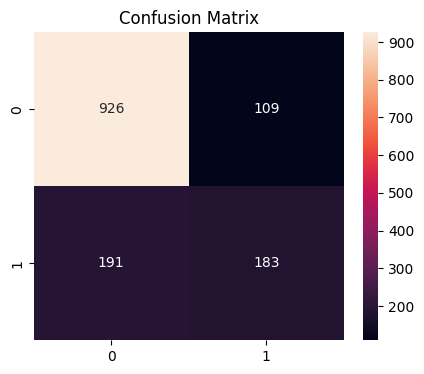

In [32]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

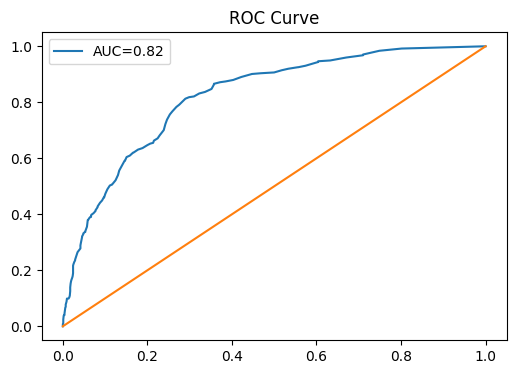

In [33]:
#ROC CURVE
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.2f}"
)

plt.plot([0,1],[0,1])

plt.legend()

plt.title("ROC Curve")

plt.show()

In [34]:
#Feature Importance (VERY IMPORTANT FOR VIVA)
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
8                     TotalCharges    0.196280
4                           tenure    0.169860
7                   MonthlyCharges    0.168515
28  PaymentMethod_Electronic check    0.040664
11     InternetService_Fiber optic    0.036985
26               Contract_Two year    0.029986
0                           gender    0.028753
6                 PaperlessBilling    0.026955
14              OnlineSecurity_Yes    0.025781
20                 TechSupport_Yes    0.023148


# Business Interpretation Report

## Business Problem

The objective of this project was to identify customers who are likely to discontinue telecom services (churn) so that the company can take preventive actions and improve customer retention. Customer churn directly impacts revenue and increases customer acquisition costs.

## Key Findings

Exploratory Data Analysis revealed that customer churn is strongly influenced by contract type, tenure, monthly charges, and additional services subscribed by customers.

Customers with month-to-month contracts showed significantly higher churn rates compared to customers with long-term contracts. Similarly, customers with shorter tenure were more likely to leave the company. Higher monthly charges were also associated with increased churn probability.

The analysis further showed that customers using services such as Online Security and Tech Support were less likely to churn, indicating that value-added services improve customer retention.

## Model Performance

Multiple machine learning models were evaluated, and Logistic Regression provided the best overall performance with approximately 80% accuracy. The model successfully identified customers at risk of churn while remaining easy to interpret for business decision-making.

## Business Insights

* Month-to-month contract customers are the most vulnerable to churn.
* New customers require special attention during their initial months.
* High monthly charges increase churn risk.
* Customers using Online Security and Tech Support are more likely to remain loyal.
* Fiber optic internet customers showed relatively higher churn rates and may require further investigation.

## Conclusion

The developed churn prediction model can help the telecom company proactively identify high-risk customers and implement targeted retention strategies. By focusing on customers with short tenure, high monthly charges, and month-to-month contracts, the company can reduce churn, improve customer satisfaction, and increase long-term profitability.


**Final Recommendation**

# Final Recommendations and Decision-Making Summary

Based on the analysis and churn prediction model results, the following recommendations are proposed for management:

## Recommendation 1: Focus on Month-to-Month Contract Customers

Customers enrolled in month-to-month contracts demonstrated the highest churn probability. The company should encourage these customers to migrate to one-year or two-year plans by offering discounts, loyalty rewards, or bundled service packages.

Expected Impact:

* Reduced churn rate
* Increased customer commitment
* Higher revenue stability

---

## Recommendation 2: Strengthen Early Customer Engagement

Customers with low tenure were identified as the most vulnerable group. The company should introduce onboarding programs, welcome offers, and regular engagement campaigns during the first 12 months.

Expected Impact:

* Improved customer satisfaction
* Increased customer retention
* Stronger long-term relationships

---

## Recommendation 3: Review Pricing Strategy

Higher monthly charges were associated with increased churn risk. Management should evaluate pricing structures and ensure customers perceive adequate value for the services provided.

Expected Impact:

* Improved price competitiveness
* Reduced price-related churn
* Increased customer trust

---

## Recommendation 4: Promote Value-Added Services

Customers using Online Security and Technical Support services exhibited lower churn rates. These services should be promoted through targeted marketing campaigns and bundled offerings.

Expected Impact:

* Higher customer engagement
* Increased customer satisfaction
* Additional revenue opportunities

---

## Recommendation 5: Investigate Fiber Optic Customer Churn

Fiber optic customers showed elevated churn rates compared to other internet service segments. Management should conduct detailed investigations into service quality, pricing, and customer complaints within this group.

Expected Impact:

* Improved service quality
* Better customer experience
* Reduced churn among high-value customers

---

## Recommendation 6: Deploy Predictive Retention System

The churn prediction model should be integrated into the customer relationship management process. Customers identified as high-risk should automatically receive retention offers, personalized communication, or service improvements.

Expected Impact:

* Proactive churn prevention
* Efficient resource allocation
* Increased customer lifetime value

---

# Final Management Decision

The company should adopt the churn prediction model as a decision-support tool and prioritize retention efforts toward customers with month-to-month contracts, short tenure, and high monthly charges. Combining predictive analytics with targeted retention initiatives can significantly reduce churn, improve customer satisfaction, and enhance long-term profitability.

The analysis indicates that customer retention can be improved through contract upgrades, personalized engagement strategies, service enhancement initiatives, and value-added service adoption programs.
